In [177]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

df = pd.read_csv('base_tratada_pede.csv', sep=';', decimal=',')

In [ ]:
#  Feature Engineering
# Definindo o Alvo (y)
df['risco_defasagem'] = np.where(df['perfil_defasagem'] == 'Em fase', 0, 1)
y = df['risco_defasagem']

# Definindo as Features (X)
colunas_features = ['fase', 'ieg', 'ida', 'ipv', 'ipp','genero_binario', 'escola_publica']
X = df[colunas_features].copy()

# Tratamento de Nulos: Imputação pela Mediana
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [179]:
# Separação em Treino e Teste
# 70% para treino, 30% para teste.
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.3, random_state=42, stratify=y)

print(f"Tamanho do Treino: {X_train.shape[0]} alunos")
print(f"Tamanho do Teste: {X_test.shape[0]} alunos")

Tamanho do Treino: 2121 alunos
Tamanho do Teste: 909 alunos


In [180]:
# Modelagem Preditiva (Random Forest)
# Criando e treinando o modelo
modelo_rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
modelo_rf.fit(X_train, y_train)

# Fazendo as previsões na base de teste
y_pred = modelo_rf.predict(X_test)

In [181]:
# Avaliação dos Resultados

print("\n--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred, target_names=['Sem Risco (0)', 'Em Risco (1)']))


--- Relatório de Classificação ---
               precision    recall  f1-score   support

Sem Risco (0)       0.65      0.54      0.59       403
 Em Risco (1)       0.68      0.77      0.72       506

     accuracy                           0.67       909
    macro avg       0.66      0.65      0.65       909
 weighted avg       0.66      0.67      0.66       909



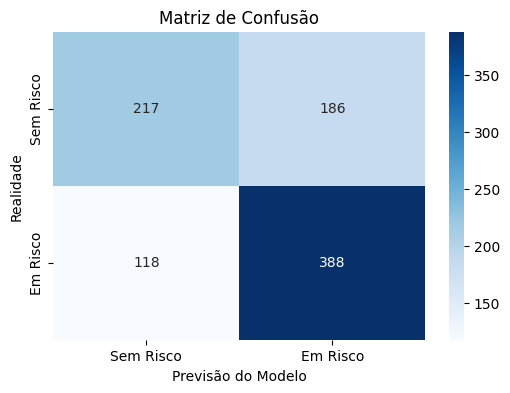

In [182]:
# Gráfico da Matriz de Confusão
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sem Risco', 'Em Risco'], yticklabels=['Sem Risco', 'Em Risco'])
plt.title('Matriz de Confusão')
plt.ylabel('Realidade')
plt.xlabel('Previsão do Modelo')
plt.show()

C:\Users\gabri\AppData\Local\Temp\ipykernel_23228\2255374907.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=importancias.values, y=importancias.index, palette='viridis')


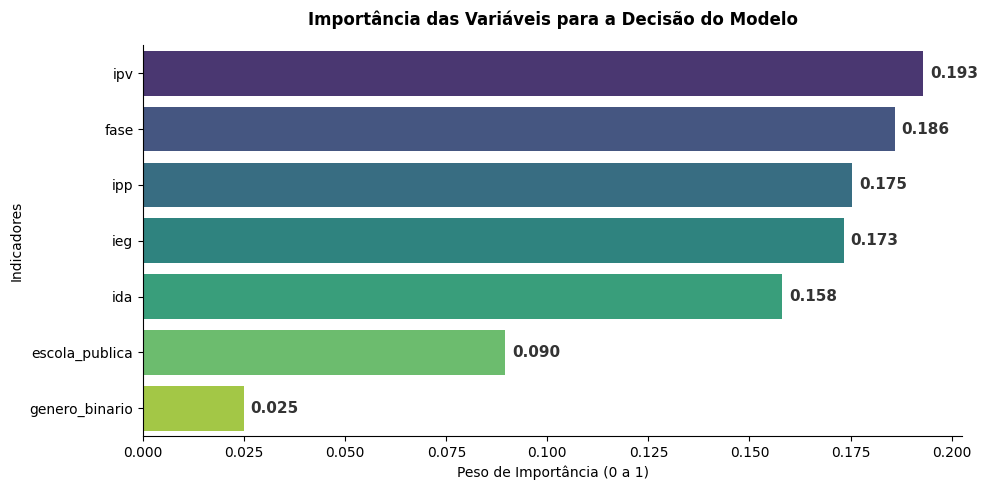

In [ ]:
# Gráfico: Importância das Variáveis
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=importancias.values, y=importancias.index, palette='viridis')

plt.title('Importância das Variáveis para a Decisão do Modelo', fontweight='bold', pad=15)
plt.xlabel('Peso de Importância (0 a 1)')
plt.ylabel('Indicadores')

for p in ax.patches:
    largura = p.get_width()
    ax.annotate(f'{largura:.3f}', 
                (largura, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                fontsize=11, fontweight='bold', color='#333333',
                xytext=(5, 0), textcoords='offset points')

sns.despine()
plt.tight_layout()
plt.show()

In [185]:
# Exportando o Modelo para o Streamlit
joblib.dump(modelo_rf, 'modelo_pede.pkl')
print("\nModelo exportado com sucesso como 'modelo_passos_magicos.pkl'!")


Modelo exportado com sucesso como 'modelo_passos_magicos.pkl'!
